In [1]:
import pandas as pd
import time
from datetime import datetime
from google_play_scraper import Sort, reviews

print("Ready!")

Ready!


In [2]:
!pip install pandas google-play-scraper  
#I had an error with the module (module not found) so i use this to reinstalled it here

In [8]:
def scrape_all_reviews(app_list):
    
    print("SCRAPING ALL GOOGLE PLAY REVIEWS")
    print("="*50)
    
    all_data = []
    app_totals = []
    
    for app in app_list:
        print(f"\n Scraping: {app}")
        
        all_reviews = []
        continuation_token = None
        
        try:
            while True:
                if continuation_token:
                    result, continuation_token = reviews(
                        app,
                        lang='en',
                        country='us',
                        sort=Sort.NEWEST,
                        count=200,
                        continuation_token=continuation_token
                    )
                else:
                    result, continuation_token = reviews(
                        app,
                        lang='en',
                        country='us',
                        sort=Sort.NEWEST,
                        count=200
                    )
                
                if not result:
                    break
                
                all_reviews.extend(result)
                time.sleep(2)
                
                if not continuation_token:
                    break
            
            if all_reviews:
                df = pd.DataFrame(all_reviews)
                df['app_name'] = app
                all_data.append(df)
                count = len(df)
                app_totals.append({'app': app, 'reviews': count})
                print(f"Done: found {count} reviews")
            else:
                app_totals.append({'app': app, 'reviews': 0})
                print(f"Done: 0 reviews")
                
        except Exception as e:
            app_totals.append({'app': app, 'reviews': 0})
            print(f"Error: {e}")
        
        time.sleep(2)
    
   
    total_reviews = sum(item['reviews'] for item in app_totals)
    apps_with_reviews = sum(1 for item in app_totals if item['reviews'] > 0)
    
    print("\n" + "="*50)
    print("FINAL SUMMARY")
    print("="*50)
    print(f"Total apps processed: {len(app_list)}")
    print(f"Apps with reviews: {apps_with_reviews}")
    print(f"Apps without reviews: {len(app_list) - apps_with_reviews}")
    print(f"\nFINAL TOTAL REVIEWS: {total_reviews}")
    print("="*50)
    
    print("\nPer-App Review Totals:")
    for item in app_totals:
        if item['reviews'] > 0:
            print(f"   {item['app']}: {item['reviews']} reviews")
        else:
            print(f"   {item['app']}: {item['reviews']} reviews (no data)")
    
    if all_data:
        return pd.concat(all_data, ignore_index=True), total_reviews, app_totals
    else:
        return pd.DataFrame(), total_reviews, app_totals

In [17]:
apps = [
    'cn.tydic.ethiopay',      # Telebirr
    'com.safarifone.ebirr',   # eBirr
    'prod.cbe.birr',          # CBE Birr
    'com.combanketh.mobilebanking',  # Commercial Bank of Ethiopia
    'com.boa.boaMobileBanking',      # Bank of Abyssinia
    'com.boa.apollo',         # BOA Apollo
    'pegasus.project.awash.mobile.android.bundle.mobilebank',  # Awash Bank
    'com.sc.awashpay',        # Awash Pay
    'com.nib.NibMobileBanking',  # NIB Bank
    'com.dashen.dashensuperapp',  # Dashen Bank
    'com.oromiabank.mobilebanking',  # Oromia Bank
    'com.coopbankoromiasc.OLB'  # Cooperative Bank of Oromia
]

print(f"Total apps to scrape: {len(apps)}")
print("\nApps being scraped:")
print("   1. Telebirr (cn.tydic.ethiopay)")
print("   2. eBirr (com.safarifone.ebirr)")
print("   3. CBE Birr (prod.cbe.birr)")
print("   4. CBE Mobile Banking (com.combanketh.mobilebanking)")
print("   5. Bank of Abyssinia Mobile Banking (com.boa.boaMobileBanking)")
print("   6. Apollo (BoA) (com.boa.apollo)")
print("   7. Awash Bank Mobilebanking (pegasus.project.awash.mobile.android.bundle.mobilebank)")
print("   8. Awash Birr Pro (com.sc.awashpay)")
print("   9. NIB Bank (com.nib.NibMobileBanking)")
print("   10. Dashen Bank Mobile banking (com.dashen.dashensuperapp)")
print("   11. Oromia Bank Mobile Banking (com.ormoibank.mobilebanking)")
print("   12. Cooperative Bank of Oromia (com.coopbankoromiasc.OLB)")

Total apps to scrape: 12

Apps being scraped:
   1. Telebirr (cn.tydic.ethiopay)
   2. eBirr (com.safarifone.ebirr)
   3. CBE Birr (prod.cbe.birr)
   4. CBE Mobile Banking (com.combanketh.mobilebanking)
   5. Bank of Abyssinia Mobile Banking (com.boa.boaMobileBanking)
   6. Apollo (BoA) (com.boa.apollo)
   7. Awash Bank Mobilebanking (pegasus.project.awash.mobile.android.bundle.mobilebank)
   8. Awash Birr Pro (com.sc.awashpay)
   9. NIB Bank (com.nib.NibMobileBanking)
   10. Dashen Bank Mobile banking (com.dashen.dashensuperapp)
   11. Oromia Bank Mobile Banking (com.ormoibank.mobilebanking)
   12. Cooperative Bank of Oromia (com.coopbankoromiasc.OLB)


In [16]:
df, grand_total, app_totals = scrape_all_reviews(apps)

SCRAPING ALL GOOGLE PLAY REVIEWS

 Scraping: cn.tydic.ethiopay
Done: found 16582 reviews

 Scraping: com.safarifone.ebirr
Done: found 1637 reviews

 Scraping: prod.cbe.birr
Done: found 2307 reviews

 Scraping: com.combanketh.mobilebanking
Done: found 9825 reviews

 Scraping: com.boa.boaMobileBanking
Done: found 1450 reviews

 Scraping: com.boa.apollo
Done: found 2080 reviews

 Scraping: pegasus.project.awash.mobile.android.bundle.mobilebank
Done: found 129 reviews

 Scraping: com.sc.awashpay
Done: found 3412 reviews

 Scraping: com.nib.NibMobileBanking
Done: found 235 reviews

 Scraping: com.dashen.dashensuperapp
Done: found 1050 reviews

 Scraping: com.oromiabank.mobilebanking
Done: found 165 reviews

 Scraping: com.coopbankoromiasc.OLB
Done: found 241 reviews

FINAL SUMMARY
Total apps processed: 12
Apps with reviews: 12
Apps without reviews: 0

FINAL TOTAL REVIEWS: 39113

Per-App Review Totals:
   cn.tydic.ethiopay: 16582 reviews
   com.safarifone.ebirr: 1637 reviews
   prod.cbe.birr

In [18]:
if not df.empty:
    print("ANALYSIS")
    print("="*50)
    
    print(f"\n FINAL TOTAL: {grand_total} reviews across all apps")
    
    if 'score' in df.columns:
        print(f"\n Average rating: {df['score'].mean():.3f}/5.0")
        print(f" Median rating: {df['score'].median():.3f}")
        
        print("\nRating breakdown:")
        pos = (df['score'] >= 4).sum()
        neu = (df['score'] == 3).sum()
        neg = (df['score'] <= 2).sum()
        print(f"   Positive (4-5 stars): {pos} ({pos/len(df)*100:.1f}%)")
        print(f"   Neutral (3 star): {neu} ({neu/len(df)*100:.1f}%)")
        print(f"   Negative (1-2 stars): {neg} ({neg/len(df)*100:.1f}%)")
    
    # Save
    filename = f"review_by_sami{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    df.to_csv(filename, index=False, encoding='utf-8')
    print(f"\n Saved: {filename}")
    
else:
    print("\n No reviews scraped!")

ANALYSIS

 FINAL TOTAL: 39113 reviews across all apps

 Average rating: 4.074/5.0
 Median rating: 5.000

Rating breakdown:
   Positive (4-5 stars): 29560 (75.6%)
   Neutral (3 star): 1931 (4.9%)
   Negative (1-2 stars): 7622 (19.5%)

 Saved: review_by_sami20260611_231604.csv


In [21]:
!pip install pandas matplotlib
import matplotlib.pyplot as plt

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 1.6 MB/s eta 0:00:05
   ----- ---------------------------------- 1.0/8.3 MB 1.7 MB/s eta 0:00:05
   ------ --------------------------------- 1.3/8.3 MB 1.7 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.3 MB 1.7 MB/s eta 0:00:04
   -------- ------------------------------- 1.8/8.3 MB 1.4 MB/s eta 0:00:05
   ---------- ----------------------------- 2.1/8.3 MB 1.3 MB/s eta 0:00:05
   ----------- ---------------------------- 2.4/8.3 MB 1.3 MB/s eta 0:00:05
   ----------- ---------------------------- 2.4/8.3 MB 1.3 MB/s eta 0:00:05
   ------------ --------------------------- 2.6/8.3 MB 1.2 MB/s eta 0:00:05
   ------------- -------------------------- 2.9/8.3 MB 1.2 MB/s eta 0:00:05
   ------------- -------------------------- 2.9/8.3 MB 1.2 MB/s eta 0:00:05
   --------------- -------

Matplotlib is building the font cache; this may take a moment.


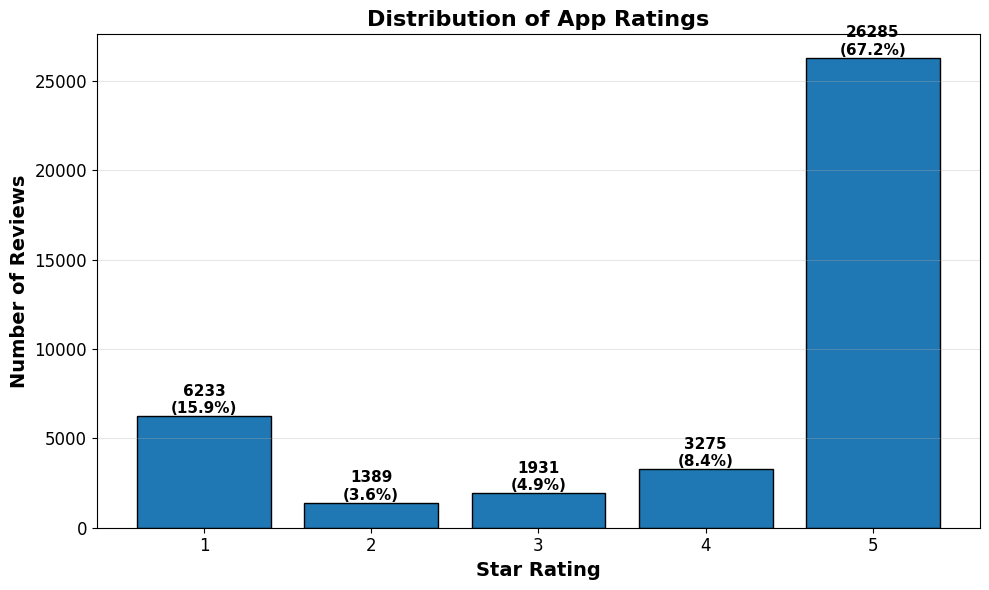


 Bar graph saved as 'rating_distribution.png'


In [23]:
if 'score' in df.columns:
        rating_counts = df['score'].value_counts().sort_index()
        
        plt.figure(figsize=(10, 6))
        bars = plt.bar(rating_counts.index, rating_counts.values, edgecolor='black', linewidth=1)
        
        plt.xlabel('Star Rating', fontsize=14, fontweight='bold')
        plt.ylabel('Number of Reviews', fontsize=14, fontweight='bold')
        plt.title('Distribution of App Ratings', fontsize=16, fontweight='bold')
        plt.xticks([1, 2, 3, 4, 5], fontsize=12)
        plt.yticks(fontsize=12)
        
        for bar, count in zip(bars, rating_counts.values):
            percentage = (count/len(df))*100
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                    f'{count}\n({percentage:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=11)
        

        plt.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('rating_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\n Bar graph saved as 'rating_distribution.png'")
        
else:
    print("\n No reviews scraped!")